# Exp 1: static–flicker recruitment

This notebook compares a pre-flicker static window with the first flicker window. Edit only the local settings below; shared calculations and figures live in `src/`.

In [22]:
# Cell 01 - Setup
from pathlib import Path
from importlib import reload
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

repo_root = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'src').is_dir())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import src.analysis_tools as at
import src.multifish_analysis as mfa
import src.plotting as plott
import src.reusable_several_fish as rsf

at, mfa, plott, rsf = reload(at), reload(mfa), reload(plott), reload(rsf)


In [23]:
# Cell 02 - Local Exp 1 settings
USER_SETTINGS = {
    'experiment_name': 'Exp_1_flickering',
    'data_base': Path(r'D:\\Alejandro\\Data'),
    # Maintained cohort from 01_all_fish_raster.ipynb.
    'fish_ids': ['L433_f02', 'L433_f04', 'L453_f09', 'L453_f11', 'L453_f08'],
    'selected_blocks': ['B1', 'B2'],
    'verbose_loading': False,
    'timing': {'fps_2p': 2.0, 't_pre_s': 5.0, 't_post_s': 32.0},
    # Validate every Exp 1 stimulus detected in the maintained map.
    'stim_order': list(range(1, 11)),
}

STATIC_FLICKER_SETTINGS = {
    # Each window is centred on its editable reference point relative to flicker onset.
    # Default: static [-6, -2) s; motion/flicker [+2, +6) s.
    'static_center_offset_s': -4.0,
    'flicker_center_offset_s': 4.0,
    # Keep these equal for paired static-versus-flicker comparisons.
    'static_window_s': 8.0,
    'flicker_window_s': 20.0,
    # A trial window is active when this many significant-raster frames are consecutive.
    'min_consecutive_active_frames': 1,
    # A neuron-side window is active when this fraction of selected stimulus-trials is active.
    'min_active_trial_fraction': 0.5,
}

REPORT_SETTINGS = {
    'save_report': False,
    'run_label': 'static_flicker_recruitment',
    'report_format': 'html',
    'export_notebook': True,
    'fallback_to_html': True,
    'comments': '',
}


In [24]:
# Cell 03 - Load and validate the maintained cohort.
raster_inputs = rsf.load_and_preflight_fish_raster_inputs(USER_SETTINGS)
globals().update(raster_inputs)
print('Detected stimulus map:', stimuli_id_map)


Detected stimulus map: {'FL1': 1, 'FL2': 2, 'FL3': 3, 'FLB': 4, 'FR1': 5, 'FR2': 6, 'FR3': 7, 'FRB': 8, 'LLB': 9, 'RLB': 10}


In [25]:
# Cell 04 - Build all left/right flicker and control results from the detected map.
side_stimuli = {
    'left': [stim_id for name, stim_id in stimuli_id_map.items() if name.startswith('FL')],
    'right': [stim_id for name, stim_id in stimuli_id_map.items() if name.startswith('FR')],
}
recruitment_results = mfa.build_static_flicker_recruitment_analysis(
    all_fish_data=all_fish_data, fish_ids=fish_ids, side_stimuli=side_stimuli,
    fps_2p=timing['fps_2p'], t_pre_s=timing['t_pre_s'],
    static_window_s=STATIC_FLICKER_SETTINGS['static_window_s'],
    flicker_window_s=STATIC_FLICKER_SETTINGS['flicker_window_s'],
    static_center_offset_s=STATIC_FLICKER_SETTINGS['static_center_offset_s'],
    flicker_center_offset_s=STATIC_FLICKER_SETTINGS['flicker_center_offset_s'],
    min_consecutive_active_frames=STATIC_FLICKER_SETTINGS['min_consecutive_active_frames'],
    min_active_trial_fraction=STATIC_FLICKER_SETTINGS['min_active_trial_fraction'],
)


In [26]:
# Cell 05 - One-fish smoke validation: windows, categories, AUCs, and figure data.
at.validate_static_flicker_recruitment_result(
    recruitment_results['per_fish'][fish_ids[0]], fps_2p=timing['fps_2p'],
)


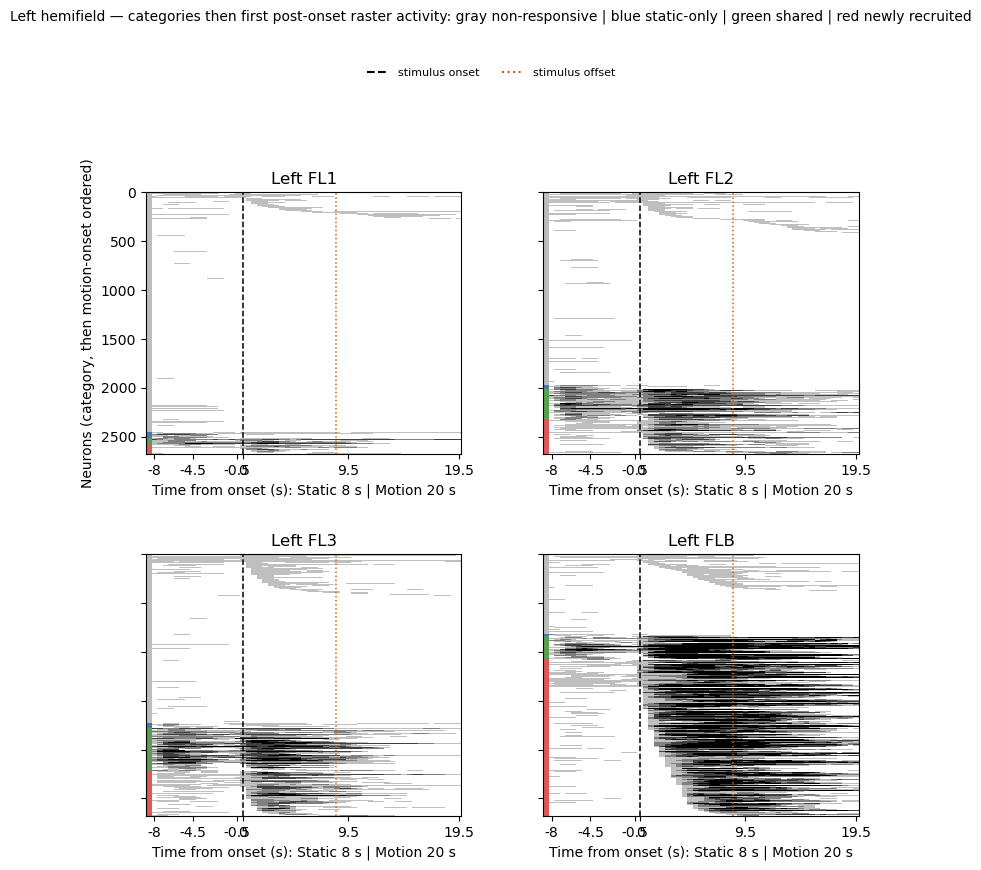

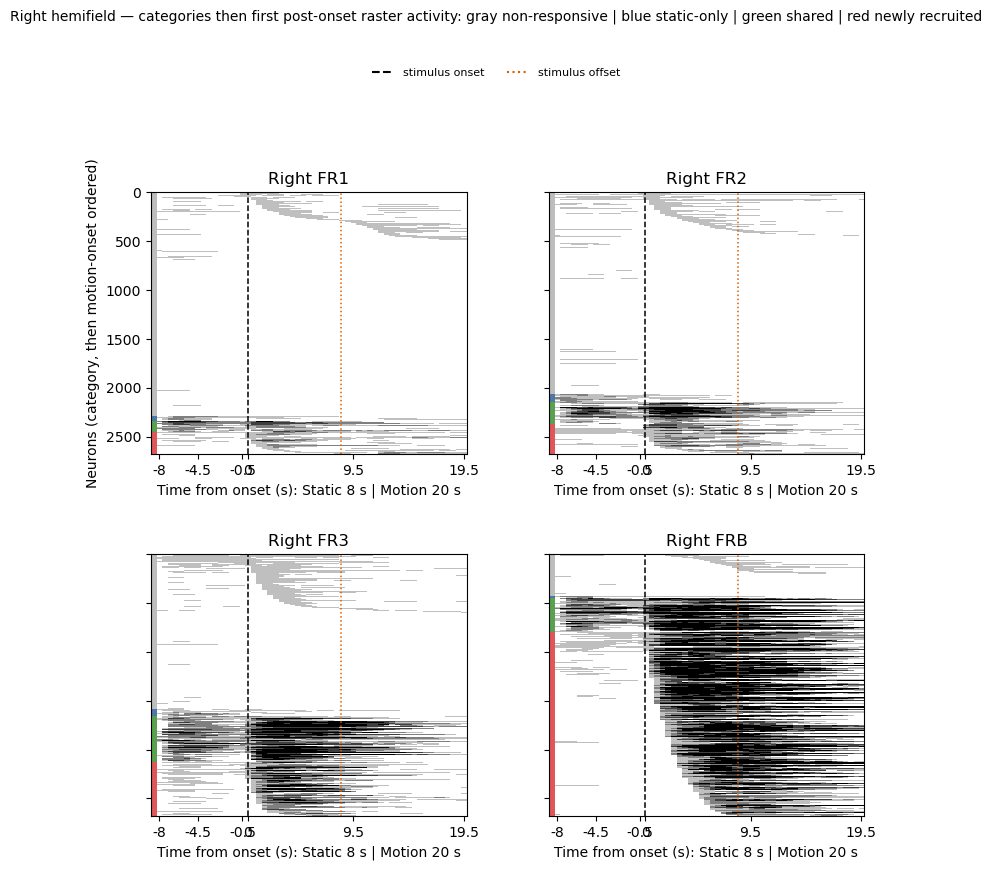

In [27]:
# Cell 06 - Edit this figure's stimuli and two independently sized time windows.
# Within each category, rows with motion activity run from earliest to latest post-onset raster activity.
CELL06_RASTER_STIMULI = {'left': [1, 2, 3, 4], 'right': [5, 6, 7, 8]}
CELL06_WINDOWS = {
    'static': {'label': 'Static', 'center_offset_s': -4.0, 'duration_s': 8.0},
    'comparison': {'label': 'Motion', 'center_offset_s': 10.0, 'duration_s': 20.0},
}
raster_plot_results = mfa.build_static_flicker_recruitment_analysis(
    all_fish_data, fish_ids, CELL06_RASTER_STIMULI, timing['fps_2p'], timing['t_pre_s'],
    CELL06_WINDOWS['static']['duration_s'], CELL06_WINDOWS['comparison']['duration_s'],
    CELL06_WINDOWS['static']['center_offset_s'], CELL06_WINDOWS['comparison']['center_offset_s'],
    STATIC_FLICKER_SETTINGS['min_consecutive_active_frames'],
    STATIC_FLICKER_SETTINGS['min_active_trial_fraction'],
)
classification_figures = plott.plot_static_flicker_classification_raster(
    raster_plot_results['classification_raster_data'],
    static_label=CELL06_WINDOWS['static']['label'],
    comparison_label=CELL06_WINDOWS['comparison']['label'],
)
display(classification_figures['left'])
plt.close(classification_figures['left'])
display(classification_figures['right'])
plt.close(classification_figures['right'])


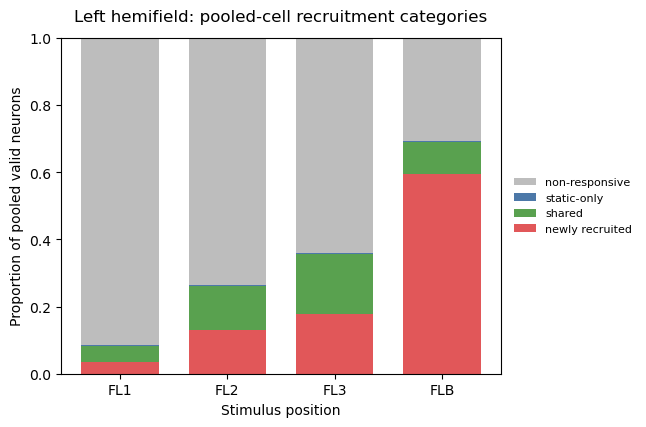

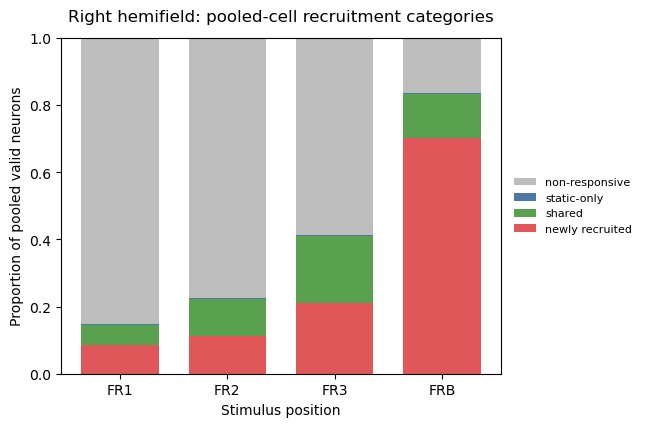

In [33]:
# Cell 07 - Edit only these lists to choose pooled-cell category-proportion bars.
CELL07_PROPORTION_STIMULI = {'left': [1, 2, 3, 4], 'right': [5, 6, 7, 8]}
cell07_stimuli = CELL07_PROPORTION_STIMULI['left'] + CELL07_PROPORTION_STIMULI['right']
# Descriptive pooled-cell view only; the visible top-to-bottom order matches Cell 06 categories.
proportion_figures = plott.plot_pooled_static_flicker_category_proportions(
    recruitment_results['pooled_category_summary'].query('stim_id in @cell07_stimuli'),
)
display(proportion_figures['left'])
plt.close(proportion_figures['left'])
display(proportion_figures['right'])
plt.close(proportion_figures['right'])


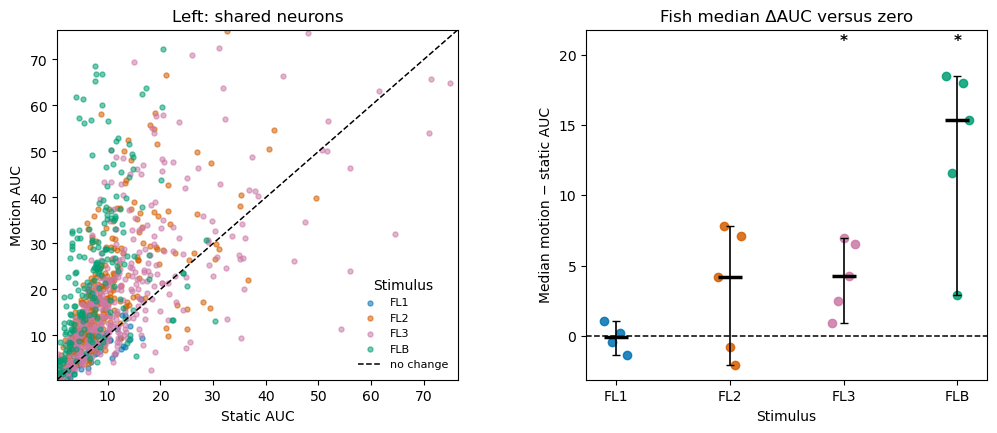

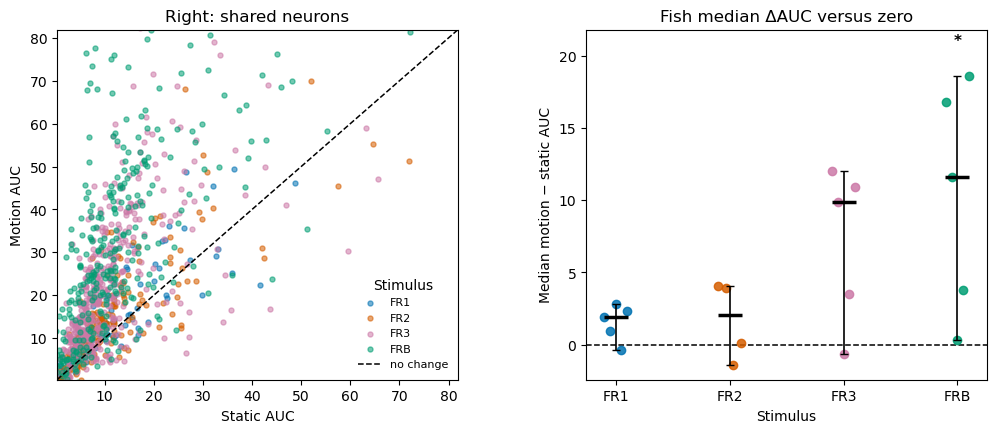

**Cell 08 interpretation.** Each coloured point in the left panel is one shared neuron (descriptive only). Each coloured point in the right panel is one fish median ΔAUC; black marker/error bar is the across-fish median and 95% bootstrap CI. The dashed diagonal/zero lines represent no static-to-motion change. Stars use the one-sided Wilcoxon signed-rank test of fish medians for ΔAUC > 0 (* p<0.05, ** p<0.01, *** p<0.001). The table below also lists paired stimulus-position contrasts.

,side,test,stimulus_a,stimulus_b,n_fish,effect_median,ci_low,ci_high,p_wilcoxon,p_holm
0,left,ΔAUC > 0,FL1,,4,-0.0994,-1.3654,1.0758,0.6875,1.0000
1,left,ΔAUC > 0,FL2,,5,4.1729,-2.0781,7.8472,0.1562,0.8750
2,left,ΔAUC > 0,FL3,,5,4.2855,0.9448,6.9853,0.0312,0.3125
3,left,ΔAUC > 0,FLB,,5,15.3455,2.9010,18.4784,0.0312,0.3125
4,left,paired position contrast,FL1,FL2,4,5.6824,-2.2996,8.4717,0.2500,1.0000
5,left,paired position contrast,FL1,FL3,4,3.4810,-0.1310,7.9060,0.2500,1.0000
6,left,paired position contrast,FL1,FLB,4,17.0568,11.9997,17.7679,0.1250,0.8750
7,left,paired position contrast,FL2,FL3,5,-0.5657,-5.3697,7.7436,0.8125,1.0000
8,left,paired position contrast,FL2,FLB,5,8.2392,3.6592,20.0675,0.0625,0.5000
9,left,paired position contrast,FL3,FLB,5,9.1017,-4.0844,17.5336,0.1250,0.8750


In [32]:
# Cell 08 - Neuron distributions are descriptive; statistics use one median ΔAUC per fish.
# One-sided Wilcoxon signed-rank tests assess the directional hypothesis ΔAUC > 0; position contrasts are two-sided.
# p_wilcoxon is uncorrected; p_holm adjusts these p-values for the multiple tests within each hemifield.
CELL08_AUC_STIMULI = {'left': [1, 2, 3, 4], 'right': [5, 6, 7, 8]}
# Edit the two sampling windows here for this statistical analysis only.
CELL08_WINDOWS = {
    'static': {'center_offset_s': -4.0, 'duration_s': 4.0},
    'motion': {'center_offset_s': 4.0, 'duration_s': 4.0},
}
if CELL08_WINDOWS['static']['duration_s'] != CELL08_WINDOWS['motion']['duration_s']:
    raise ValueError('Cell 08 requires equal static and motion durations for paired ΔAUC inference.')
cell08_stimuli = CELL08_AUC_STIMULI['left'] + CELL08_AUC_STIMULI['right']
auc_plot_results = mfa.build_static_flicker_recruitment_analysis(
    all_fish_data, fish_ids, CELL08_AUC_STIMULI, timing['fps_2p'], timing['t_pre_s'],
    CELL08_WINDOWS['static']['duration_s'], CELL08_WINDOWS['motion']['duration_s'],
    CELL08_WINDOWS['static']['center_offset_s'], CELL08_WINDOWS['motion']['center_offset_s'],
    STATIC_FLICKER_SETTINGS['min_consecutive_active_frames'],
    STATIC_FLICKER_SETTINGS['min_active_trial_fraction'],
)
cell08_labels = {side: auc_plot_results['fish_median_delta_auc'].loc[
    lambda table: (table['side'] == side) & table['stim_id'].isin(selected), 'stimulus'
].unique() for side, selected in CELL08_AUC_STIMULI.items()}
all_cell08_statistics = mfa.compute_static_flicker_fish_level_statistics(
    auc_plot_results['fish_median_delta_auc']
)
cell08_statistics = pd.concat([
    all_cell08_statistics.loc[
        lambda table: (table['side'] == side) & table['stimulus_a'].isin(cell08_labels[side])
        & ((table['stimulus_b'] == '') | table['stimulus_b'].isin(cell08_labels[side]))
    ] for side in CELL08_AUC_STIMULI], ignore_index=True)
auc_figures = plott.plot_shared_static_flicker_auc_summary(
    auc_plot_results['shared_neuron_metrics'],
    auc_plot_results['fish_median_delta_auc'],
    cell08_statistics,
)
display(auc_figures['left'])
plt.close(auc_figures['left'])
display(auc_figures['right'])
plt.close(auc_figures['right'])

display(Markdown(
    '**Cell 08 interpretation.** Each coloured point in the left panel is one shared neuron (descriptive only). '
    'Each coloured point in the right panel is one fish median ΔAUC; black marker/error bar is the across-fish median and 95% bootstrap CI. '
    'The dashed diagonal/zero lines represent no static-to-motion change. Stars use the one-sided Wilcoxon signed-rank test of fish medians for ΔAUC > 0 '
    '(* p<0.05, ** p<0.01, *** p<0.001). The table below also lists paired stimulus-position contrasts.'
))

CELL08_TEST_TABLE = cell08_statistics[['side', 'test', 'stimulus_a', 'stimulus_b', 'n_fish', 'effect_median', 'ci_low', 'ci_high', 'p_wilcoxon', 'p_holm']]
display(CELL08_TEST_TABLE.round(4))


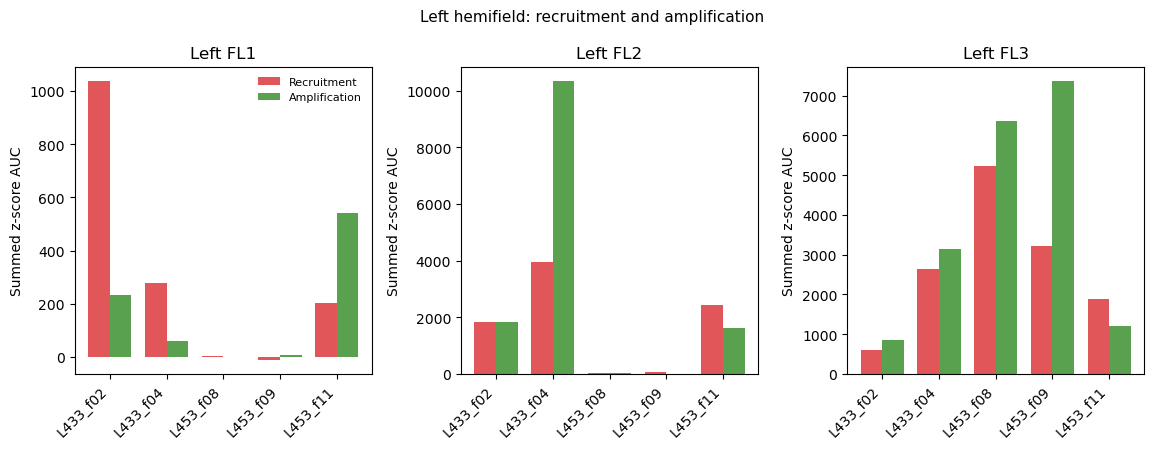

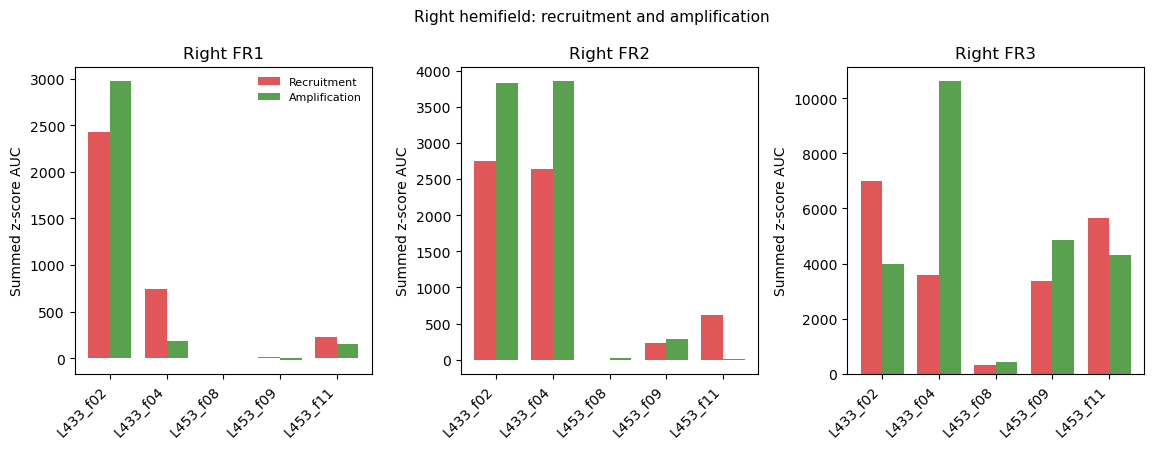

In [30]:
# Cell 09 - Edit only these lists to choose recruitment/amplification panels.
CELL09_DECOMPOSITION_STIMULI = {'left': [1, 2, 3], 'right': [5, 6, 7]}
cell09_stimuli = CELL09_DECOMPOSITION_STIMULI['left'] + CELL09_DECOMPOSITION_STIMULI['right']
decomposition_figures = plott.plot_recruitment_amplification(
    recruitment_results['recruitment_amplification'].query('stim_id in @cell09_stimuli'),
)
display(decomposition_figures['left'])
plt.close(decomposition_figures['left'])
display(decomposition_figures['right'])
plt.close(decomposition_figures['right'])


In [31]:
# Cell 10 - Optional HTML report and compact per-fish CSV summaries.
if REPORT_SETTINGS['save_report']:
    report_result = rsf.save_analysis_report_run(
        settings=USER_SETTINGS, report_settings=REPORT_SETTINGS, analysis_path=analysis_path,
        tables={
            'fish_side_categories': recruitment_results['fish_side_summary'],
            'fish_side_shared_delta_auc': recruitment_results['fish_median_delta_auc'],
            'fish_side_recruitment_amplification': recruitment_results['recruitment_amplification'],
        },
        notebook_path=repo_root / 'scripts' / 'calcium_analysis' / 'Exp_1_flickering' / '02_static_flicker_recruitment.ipynb',
        report_name='02_static_flicker_recruitment_report',
        extra_metadata={'side_stimuli': side_stimuli, **STATIC_FLICKER_SETTINGS},
    )
